### This notebook thresholds the weights in the Ridge model according to the NNLS to see onlythe effect of high weights

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.summarize as ccs
import cortico_cereb_connectivity.globals as gl
import Functional_Fusion.atlas_map as am
import SUITPy as suit

In [8]:
def vox_corr(X, Y):
    """Compute the correlation between two matrices X and Y along the second axis."""
    X = X - np.mean(X, axis=1, keepdims=True)
    Y = Y - np.mean(Y, axis=1, keepdims=True)
    corr = np.sum(X * Y, axis=1) / (np.sqrt(np.sum(X**2, axis=1)) * np.sqrt(np.sum(Y**2, axis=1)))
    return corr

### Only for the Global Global model

/localscratch/tmp/ipykernel_660327/603426927.py:5: RuntimeWarning: invalid value encountered in divide
  corr = np.sum(X * Y, axis=1) / (np.sqrt(np.sum(X**2, axis=1)) * np.sqrt(np.sum(Y**2, axis=1)))


NNLS correlation with L2reg: 0.35 ± 0.05
NNLS correlation with top 4%: 0.55 ± 0.10
NNLS correlation with sparseness per voxel: 0.56 ± 0.09
NNLS correlation with masked: 0.83 ± 0.03


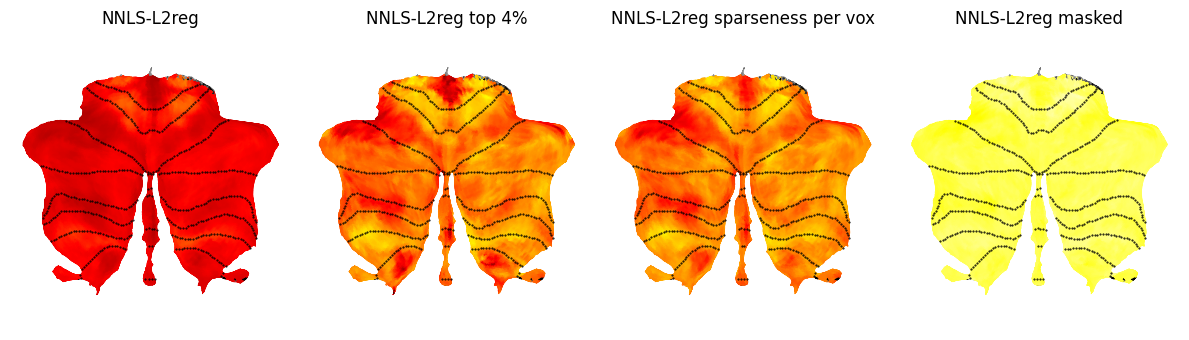

In [10]:
do_plot = True
atlas, _ = am.get_atlas('MNISymC3')
labels = ['L2reg', 'L2reg top 4%', 'L2reg sparseness per vox', 'L2reg masked']

# load models
NNLS_mo, _ = ccs.get_model(''.join(gl.dscode), 'Icosahedron1002', 'NNLS', 'A0_global', cerebellum_atlas='MNISymC3')
L2reg_mo, _ = ccs.get_model(''.join(gl.dscode), 'Icosahedron1002', 'L2reg', 'A2_global', cerebellum_atlas='MNISymC3')

# alter Ridge coefficients
thresh = np.percentile(L2reg_mo.coef_, 96)
thresh_vox = np.sum(NNLS_mo.coef_ > 0, axis=1)
L2reg_high_coef = np.where(L2reg_mo.coef_ >= thresh, L2reg_mo.coef_, 0)
L2reg_high_coef_vox = np.zeros_like(L2reg_mo.coef_)
for v, n in enumerate(thresh_vox):
    L2reg_idx = np.argsort(L2reg_mo.coef_[v])[-n:]
    L2reg_high_coef_vox[v][L2reg_idx] = L2reg_mo.coef_[v][L2reg_idx]
L2reg_mask_coef = np.where(NNLS_mo.coef_ > 0, L2reg_mo.coef_, 0)

# correlation
corr_L2reg = vox_corr(L2reg_mo.coef_, NNLS_mo.coef_)
corr_top = vox_corr(L2reg_high_coef, NNLS_mo.coef_)
corr_top_vox = vox_corr(L2reg_high_coef_vox, NNLS_mo.coef_)
corr_masked = vox_corr(L2reg_mask_coef, NNLS_mo.coef_)

# display
print(f'NNLS correlation with L2reg: {np.nanmean(corr_L2reg):.2f} ± {np.nanstd(corr_L2reg):.2f}')
print(f'NNLS correlation with top 4%: {np.nanmean(corr_top):.2f} ± {np.nanstd(corr_top):.2f}')
print(f'NNLS correlation with sparseness per voxel: {np.nanmean(corr_top_vox):.2f} ± {np.nanstd(corr_top_vox):.2f}')
print(f'NNLS correlation with masked: {np.nanmean(corr_masked):.2f} ± {np.nanstd(corr_masked):.2f}')

# plot
if do_plot:
    plt.subplots(1, 4, figsize=(12, 3.5), tight_layout=True)
    for i, W_corr in enumerate([corr_L2reg, corr_top, corr_top_vox, corr_masked]):
        W_data = suit.vol_to_surf(atlas.data_to_nifti(W_corr), space='MNISymC')
        plt.subplot(1, 4, i+1)
        plt.title(f'NNLS-{labels[i]}')
        suit.flatmap.plot(W_data, cmap='hot', new_figure=False, bordersize=1, cscale=[0, 1])
    plt.show()

Prediction Correlation (R = 0.56 ± 0.09)


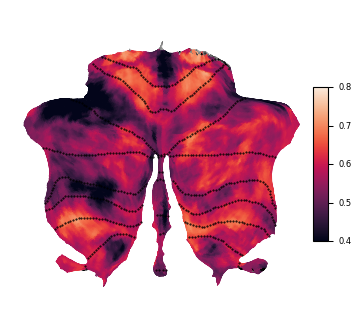

In [12]:
fig = plt.figure(figsize=(4.6,4))
W_data = suit.vol_to_surf(atlas.data_to_nifti(corr_top_vox), space='MNISymC')
suit.flatmap.plot(W_data, cmap='rocket', new_figure=False, colorbar=True, cscale=[0.4, 0.8], bordersize=1)
for cax in fig.axes:
    cax.tick_params(axis='both', labelsize=6, width=0.75)

print(f'Prediction Correlation (R = {np.array(corr_top_vox).mean():.2f} ± {np.array(corr_top_vox).std():.2f})')
plt.savefig(gl.fig_dir + "/fig02_d.pdf", dpi=400, bbox_inches='tight');

In [ ]:
random_state = 42
rng = np.random.default_rng(random_state)
from tqdm import tqdm
import warnings

n_perm = 100
null_dist = np.zeros(n_perm)

# permutation testing
for k in tqdm(range(n_perm)):
    shuffled = np.array([np.random.permutation(row) for row in L2reg_high_coef])
    with warnings.catch_warnings(record=True) as w:
        perm_corrs = vox_corr(shuffled, NNLS_mo.coef_)
    null_dist[k] = np.nanmean(perm_corrs)

100%|██████████| 100/100 [00:42<00:00,  2.37it/s]


In [22]:
# test
p_value = np.mean(null_dist >= np.nanmean(corr_top))
print(f"P-value = {p_value:.2f}")

P-value = 0.00


In [25]:
P = NNLS_mo.coef_.shape[0]
dice_scores = np.zeros(P)

for p in range(P):
    Sa = NNLS_mo.coef_[p] > 0
    Sb = L2reg_high_coef[p] > 0

    intersection = np.sum(Sa & Sb)

    dice = (2 * intersection) / (np.sum(Sa) + np.sum(Sb))

    dice_scores[p] = dice

print(f"Mean Dice: {np.mean(dice_scores):.2f}")

Mean Dice: 0.42


In [32]:
import numpy as np
from scipy.stats import pearsonr

def fast_perm_test(A, Bpp, n_perm=1000, seed=0):

    rng = np.random.default_rng(seed)

    P, Q = A.shape

    # -------------------------
    # Precompute support masks
    # -------------------------
    masks = [A[p] > 0 for p in range(P)]

    # extract values per row once
    B_vals = [Bpp[p, m].copy() for p, m in enumerate(masks)]
    A_vals = [A[p, m] for p, m in enumerate(masks)]

    # -------------------------
    # function to compute score
    # -------------------------
    def score(B_list):
        corrs = []

        for p in range(P):
            a = A_vals[p]
            b = B_list[p]

            if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
                continue

            corrs.append(np.corrcoef(a, b)[0, 1])

        return np.nanmean(corrs)

    # observed
    observed = score(B_vals)

    # -------------------------
    # permutation test
    # -------------------------
    null = np.empty(n_perm)

    for k in tqdm(range(n_perm)):

        B_perm = []

        for p in range(P):
            vals = B_vals[p]
            B_perm.append(rng.permutation(vals))   # vectorized shuffle

        null[k] = score(B_perm)

    p_value = np.nanmean(null >= observed)

    return observed, null, p_value

observed, null, p_value = fast_perm_test(NNLS_mo.coef_, L2reg_mask_coef, n_perm=100)

100%|██████████| 100/100 [01:13<00:00,  1.36it/s]


In [33]:
print(f"Observed correlation: {observed:.2f}")
print(f"P-value: {p_value:.2e}")

Observed correlation: 0.56
P-value: 0.00e+00
